# Train ML Models for modelling the competitors' prices

This notebook train the ML models in order to create the constraints for the optimization problem. The models are trained using the data generated in the DataGenerationROBIN module.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
from torchview import draw_graph

from models.dnn import FeedForwardNN
from utils import *

# Allow pandas to display all columns
pd.set_option("display.max_columns", None)

## Load the dataset and preprocess it

In [3]:
path_data = "../../DataGenerationROBIN/data/MAD-BCN/aggregated/MAD-BCN_2025_RENFE.csv"

data = pd.read_csv(path_data, sep=",")

y_col = "price"  # The price of the service
y = data[y_col]
X = data.drop(columns=[y_col], axis=1, inplace=False)
X_processed = X.copy()

data.columns

Index(['service_id', 'train_type', 'capacity', 'train_model', 'year', 'month',
       'day_of_week', 'departure_time', 'duration', 'price', 'passengers',
       'time_distance_competitor_-2', 'price_competitor_-2',
       'train_type_competitor_-2', 'duration_competitor_-2',
       'time_distance_competitor_-1', 'price_competitor_-1',
       'train_type_competitor_-1', 'duration_competitor_-1',
       'time_distance_competitor_1', 'price_competitor_1',
       'train_type_competitor_1', 'duration_competitor_1',
       'time_distance_competitor_2', 'price_competitor_2',
       'train_type_competitor_2', 'duration_competitor_2'],
      dtype='object')

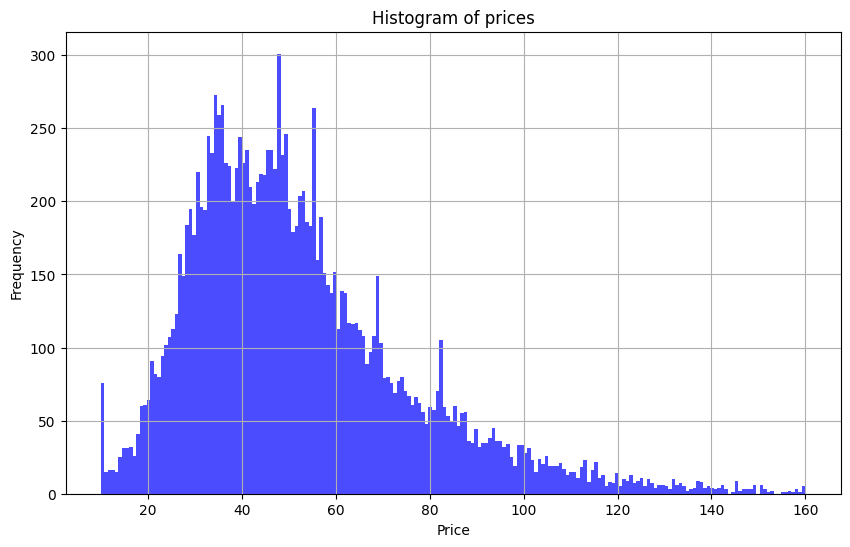

In [4]:
# Plot the histogram of prices
plt.figure(figsize=(10, 6))
plt.hist(y, bins=200, color="blue", alpha=0.7)
plt.title("Histogram of prices")
plt.xlabel("Price") 
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [5]:
## Process temporal features

# Create new column 'weekend' based on 'day_of_week'
#X_processed["weekend"] = (X_processed["day_of_week"] >= 5).astype(int)


# Apply sine/cosine transformation to the columns: 'month', 'day_of_week', 'departure_time'
def sine_cosine_transform(df, col, period, drop=False):
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)
    if drop:
        df.drop(columns=[col], inplace=True)
    return df

X_processed = sine_cosine_transform(X_processed, "month", 12, drop=True)
X_processed = sine_cosine_transform(X_processed, "day_of_week", 7, drop=True)


In [6]:
## Process categorical features

# Apply one-hot encoding to the columns: 'train_type' and train_type_competitor_i
cols_to_encode = ["train_type"] #+ [
#    f"train_type_competitor_{i}" for i in range(-2, 3) if i != 0
#]

# Use pandas get_dummies to one-hot encode the specified columns
#X_processed = pd.get_dummies(
#    X_processed, columns=cols_to_encode, drop_first=False, dtype=int
#)

In [7]:
## Remove unused columns
X_processed.drop(
    columns=['service_id', 'capacity', 'train_model', 'year', #'month', #'day_of_week'
        'departure_time', 'passengers'] + [
        f"duration_competitor_{i}" for i in range(-2, 3) if i != 0
        ] + [
        f"train_type_competitor_{i}" for i in range(-2, 3) if i != 0
        ],
    inplace=True
)
print(X_processed.columns)

Index(['train_type', 'duration', 'time_distance_competitor_-2',
       'price_competitor_-2', 'time_distance_competitor_-1',
       'price_competitor_-1', 'time_distance_competitor_1',
       'price_competitor_1', 'time_distance_competitor_2',
       'price_competitor_2', 'month_sin', 'month_cos', 'day_of_week_sin',
       'day_of_week_cos'],
      dtype='object')


In [8]:
# Filter prices on only one company
mask = X_processed["train_type"] == "IRYO" #"OUIGO"
X_processed = X_processed[mask].copy()
y = y[mask].copy()


X_processed.drop(
    columns=["train_type"], inplace=True,
)

In [9]:
## Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=2026, shuffle=False)

#X_train = X_processed.copy()
#X_test = X_processed.copy()
#y_train = y.copy()
#y_test = y.copy()

print(f"Number of training samples: {len(X_train)}, Number of testing samples: {len(X_test)}")

Number of training samples: 3712, Number of testing samples: 929


In [10]:
## Scale the features

scaled_feat = (
    ["duration"]
    #+ [f"duration_competitor_{i}" for i in range(-2, 3) if i != 0]
    + [f"time_distance_competitor_{i}" for i in range(-2, 3) if i != 0]
    + [f"price_competitor_{i}" for i in range(-2, 3) if i != 0]
)

# Scale the features
feat_scaler = StandardScaler()
X_train[scaled_feat] = feat_scaler.fit_transform(X_train[scaled_feat])
X_test[scaled_feat] = feat_scaler.transform(X_test[scaled_feat])

# Scale the target variable
target_scaler = StandardScaler()
y_train = pd.DataFrame(target_scaler.fit_transform(y_train.values.reshape(-1, 1)), columns = [y.name])
y_test = pd.DataFrame(target_scaler.transform(y_test.values.reshape(-1, 1)), columns = [y.name])


In [11]:
## Describe the training data
X_train.describe()

,duration,time_distance_competitor_-2,price_competitor_-2,time_distance_competitor_-1,price_competitor_-1,time_distance_competitor_1,price_competitor_1,time_distance_competitor_2,price_competitor_2,month_sin,month_cos,day_of_week_sin,day_of_week_cos
count,3.712000e+03,3.712000e+03,3.712000e+03,3.712000e+03,3.712000e+03,3.712000e+03,3.712000e+03,3.712000e+03,3.712000e+03,3712.000000,3712.000000,3712.000000,3712.000000
mean,-4.932596e-16,4.247082e-18,4.105911e-16,4.235118e-17,-1.196361e-16,-2.292228e-16,3.991060e-16,5.024716e-18,4.259045e-17,0.079382,-0.218206,0.059817,0.013613
std,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,0.748097,0.621844,0.690321,0.721084
min,-1.436120e+00,-4.101278e+00,-2.187090e+00,-9.171772e+00,-1.896290e+00,-7.835927e-01,-1.714252e+00,-3.388722e-01,-2.016896e+00,-1.000000,-1.000000,-0.974928,-0.900969
25%,-1.436120e+00,-1.816246e-03,-7.119019e-01,-6.327021e-02,-6.916057e-01,-7.835927e-01,-7.075396e-01,-3.247026e-01,-7.000709e-01,-0.866025,-0.866025,-0.433884,-0.900969
50%,5.674672e-01,2.921436e-01,-9.466265e-02,1.381303e-01,-1.888825e-01,-7.308837e-01,-2.253510e-01,-9.798870e-02,-1.684637e-01,0.500000,-0.500000,0.000000,-0.222521
75%,5.674672e-01,3.560479e-01,5.635088e-01,2.485758e-01,5.689982e-01,1.008515e+00,4.166701e-01,1.536823e-02,4.416017e-01,0.866025,0.500000,0.781831,0.623490
max,1.502475e+00,4.263427e-01,4.208569e+00,3.590213e-01,3.507939e+00,3.169586e+00,3.667317e+00,9.112262e+00,4.344579e+00,1.000000,0.866025,0.974928,1.000000


In [12]:
X_train

,duration,time_distance_competitor_-2,price_competitor_-2,time_distance_competitor_-1,price_competitor_-1,time_distance_competitor_1,price_competitor_1,time_distance_competitor_2,price_competitor_2,month_sin,month_cos,day_of_week_sin,day_of_week_cos
2,-1.436120,0.317705,-0.061405,0.138130,0.656026,-0.783593,-1.077074,-0.338872,-0.412956,0.500000,0.866025,0.974928,-0.222521
6,-1.436120,0.426343,-0.427935,0.359021,1.454828,1.008515,0.187595,-0.097989,0.393255,0.500000,0.866025,0.974928,-0.222521
8,0.567467,0.317705,2.211263,0.138130,-0.083894,-0.783593,0.324645,0.015368,-0.359520,0.500000,0.866025,0.974928,-0.222521
10,0.567467,0.292144,0.278611,0.086156,0.057572,1.430187,-0.312174,0.312930,-0.306932,0.500000,0.866025,0.974928,-0.222521
13,0.567467,-0.001816,0.456294,-0.186709,-0.599764,-0.783593,-0.267686,0.015368,-0.818818,0.500000,0.866025,0.974928,-0.222521
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11994,0.567467,0.282558,0.817707,0.066666,1.374096,-0.730884,1.136903,-0.324703,0.053552,-0.866025,0.500000,-0.781831,0.623490
11997,0.567467,0.356048,1.509369,0.222589,-0.239062,-0.783593,0.882176,-0.218430,2.615954,-0.866025,0.500000,-0.781831,0.623490
12002,-1.436120,-4.101278,2.894087,0.300550,-1.290430,-0.783593,-0.044889,-0.338872,0.565438,-0.866025,0.500000,0.000000,1.000000
12006,-1.436120,0.317705,-0.022799,0.138130,0.207926,-0.783593,-0.665563,-0.338872,-0.148319,-0.866025,0.500000,0.000000,1.000000


## Train a Random Forest Regression model

## Train a Feedforward Neural Network

In [13]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# If y is a 1D vector, we need to add an extra dimension
if y_train_tensor.ndim == 1:
    y_train_tensor = y_train_tensor.unsqueeze(1)

# DataLoader for training data
training_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(training_dataset, batch_size=128, shuffle=True)

In [14]:
input_size = X_train_tensor.shape[1]
output_size = 1
#hidden_layers = [128, 64, 32]
#hidden_layers = [64, 32]
hidden_layers = [256]
drop = 0.2

ffnn_model = FeedForwardNN(input_size, output_size, hidden_layers, drop)

print(summary(ffnn_model, input_size=(input_size,)))

# graph = draw_graph(
#     model = ffnn_model,
#     expand_nested = True,
#     input_size = (128,input_size),
#     graph_name = 'FeedForwardNN'
# )
# graph.visual_graph

Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─Linear: 2-1                       3,584
├─Linear: 1-2                            257
├─ModuleList: 1-3                        --
|    └─Dropout: 2-2                      --
Total params: 3,841
Trainable params: 3,841
Non-trainable params: 0
Layer (type:depth-idx)                   Param #
├─ModuleList: 1-1                        --
|    └─Linear: 2-1                       3,584
├─Linear: 1-2                            257
├─ModuleList: 1-3                        --
|    └─Dropout: 2-2                      --
Total params: 3,841
Trainable params: 3,841
Non-trainable params: 0


In [15]:
class QuantileLoss(nn.Module):
    def __init__(self, quantile):
        super().__init__()
        self.q = quantile

    def forward(self, y_pred, y_true):
        e = y_true - y_pred
        return torch.mean(torch.maximum(self.q * e, (self.q - 1) * e))


class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        loss = torch.log(torch.cosh(y_pred - y_true))
        return torch.mean(loss)


# Función de pérdida y optimizador
# criterion = nn.MSELoss()
criterion = nn.L1Loss()
# criterion = nn.HuberLoss(delta=1)
# criterion = QuantileLoss(quantile=0.3)
# criterion = LogCoshLoss()
optimizer = optim.Adam(ffnn_model.parameters(), lr=1e-3, weight_decay=1e-5)

# Scheduler: reduce el LR si la val_loss no mejora tras 'patience' épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                 factor=0.9, patience=10, 
                                                 verbose=True)


# Entrenamiento del modelo
loss_history = []
r2_history = []
mape_history = []

n_epochs = 1000
for epoch in range(n_epochs):
    epoch_loss = 0.0
    y_true_epoch = []
    y_pred_epoch = []

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ffnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        y_true_epoch.extend(batch_y.detach().numpy())
        y_pred_epoch.extend(outputs.detach().numpy())

    # Convert the lists to numpy arrays for metric calculations
    y_true_epoch = np.array(y_true_epoch).flatten()
    y_pred_epoch = np.array(y_pred_epoch).flatten()

    avg_loss = epoch_loss / len(train_loader)
    r2 = r2_score(y_true_epoch, y_pred_epoch)
    mape = smape(y_true_epoch, y_pred_epoch)

    loss_history.append(avg_loss)
    r2_history.append(r2)
    mape_history.append(mape)

    # Update the learning rate scheduler
    scheduler.step(avg_loss)

    print(
        f"Epoch {epoch + 1}/{n_epochs} - Loss: {avg_loss:.4f} - R²: {r2:.4f} - sMAPE: {mape:.2f} - LR: {optimizer.param_groups[0]['lr']:.6f}"
    )


/Users/joseangel/miniforge3/envs/dcl-trainmarket/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/1000 - Loss: 0.6666 - R²: 0.2278 - sMAPE: 125.89 - LR: 0.001000
Epoch 2/1000 - Loss: 0.5806 - R²: 0.4602 - sMAPE: 107.06 - LR: 0.001000
Epoch 3/1000 - Loss: 0.5482 - R²: 0.5205 - sMAPE: 103.25 - LR: 0.001000
Epoch 4/1000 - Loss: 0.5256 - R²: 0.5630 - sMAPE: 101.17 - LR: 0.001000
Epoch 5/1000 - Loss: 0.5089 - R²: 0.5907 - sMAPE: 99.56 - LR: 0.001000
Epoch 6/1000 - Loss: 0.4974 - R²: 0.6086 - sMAPE: 98.75 - LR: 0.001000
Epoch 7/1000 - Loss: 0.4926 - R²: 0.6168 - sMAPE: 96.75 - LR: 0.001000
Epoch 8/1000 - Loss: 0.4826 - R²: 0.6325 - sMAPE: 96.47 - LR: 0.001000
Epoch 9/1000 - Loss: 0.4792 - R²: 0.6377 - sMAPE: 95.60 - LR: 0.001000
Epoch 10/1000 - Loss: 0.4762 - R²: 0.6417 - sMAPE: 95.43 - LR: 0.001000
Epoch 11/1000 - Loss: 0.4751 - R²: 0.6423 - sMAPE: 95.31 - LR: 0.001000
Epoch 12/1000 - Loss: 0.4733 - R²: 0.6451 - sMAPE: 94.38 - LR: 0.001000
Epoch 13/1000 - Loss: 0.4704 - R²: 0.6480 - sMAPE: 94.01 - LR: 0.001000
Epoch 14/1000 - Loss: 0.4672 - R²: 0.6525 - sMAPE: 93.91 - LR: 0.0010

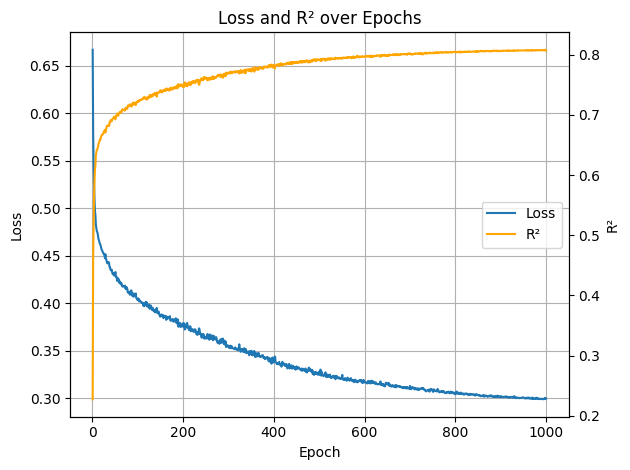

In [16]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Eje izquierdo: pérdida
ax1.plot(range(1, n_epochs + 1), loss_history, label="Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Eje derecho: R^2
ax2 = ax1.twinx()
ax2.plot(range(1, n_epochs + 1), r2_history, color="orange", label="R²")
ax2.set_ylabel("R²")

# Leyenda combinada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")

plt.title("Loss and R² over Epochs")
plt.tight_layout()
plt.show()

In [17]:
## Execute the model on the test set
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# If y is a 1D vector, we need to add an extra dimension
if y_test_tensor.ndim == 1:
    y_test_tensor = y_test_tensor.unsqueeze(1)
# DataLoader for test data
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

y_true_test = []
y_pred_test = []
for batch_X, batch_y in test_loader:
    with torch.no_grad():
        outputs = ffnn_model(batch_X)
        y_true_test.extend(batch_y.numpy())
        y_pred_test.extend(outputs.numpy())

# Convert the lists to numpy arrays for metric calculations
y_true_test = np.array(y_true_test).flatten()
y_pred_test = np.array(y_pred_test).flatten()


# y_true_test = np.expm1(y_true_test) # Inverse log transformation
# y_pred_test = np.expm1(y_pred_test) # Inverse log transformation

y_true_test = y_true_test * target_scaler.scale_[0] + target_scaler.mean_[0]
y_pred_test = y_pred_test * target_scaler.scale_[0] + target_scaler.mean_[0]



## Evaluate the model

In [18]:
# Evaluate the model
mape = mean_absolute_percentage_error(y_true_test, y_pred_test)
mse = mean_squared_error(y_true_test, y_pred_test)
r2 = r2_score(y_true_test, y_pred_test)
smape_value = smape(y_true_test, y_pred_test)
print(f"MAPE: {mape:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")
print(f"sMAPE: {smape_value:.4f}")

MAPE: 0.2780
MSE: 147.3571
R2: 0.5791
sMAPE: 23.9091


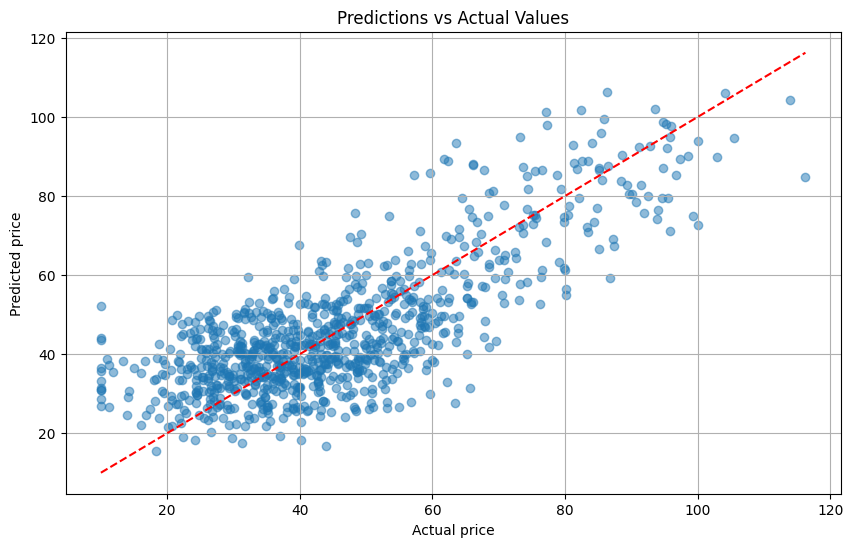

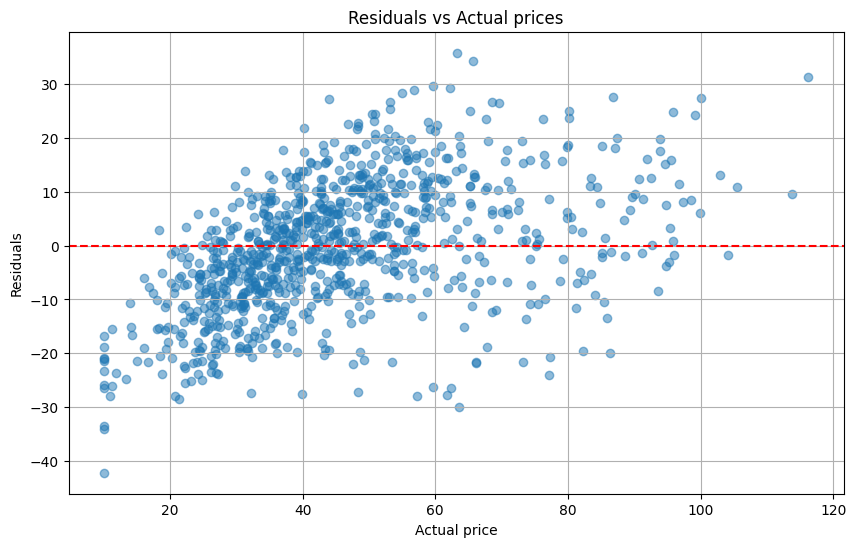

In [19]:
# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], color='red', linestyle='--')
plt.title("Predictions vs Actual Values")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.grid()
plt.show()

# Plot the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_true_test, y_true_test - y_pred_test, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Actual prices")
plt.xlabel("Actual price")
plt.ylabel("Residuals")
plt.grid()
plt.show()

In [20]:
# Count number of instances at a distance < d of the real value
def count_within_distance(y_true, y_pred, distance):
    n_instances = np.sum(np.abs(y_pred - y_true) < distance)
    percentage = np.round((n_instances / len(y_true)) * 100, 2)
    return n_instances, percentage

print(f"Percentage of instances with prediction within 5 euros of the real value: {count_within_distance(y_true_test, y_pred_test, 5)[1]}")
print(f"Percentage of instances with prediction within 10 euros of the real value: {count_within_distance(y_true_test, y_pred_test, 10)[1]}")
print(f"Percentage of instances with prediction within 20 euros of the real value: {count_within_distance(y_true_test, y_pred_test, 20)[1]}")


Percentage of instances with prediction within 5 euros of the real value: 30.68
Percentage of instances with prediction within 10 euros of the real value: 58.34
Percentage of instances with prediction within 20 euros of the real value: 90.1


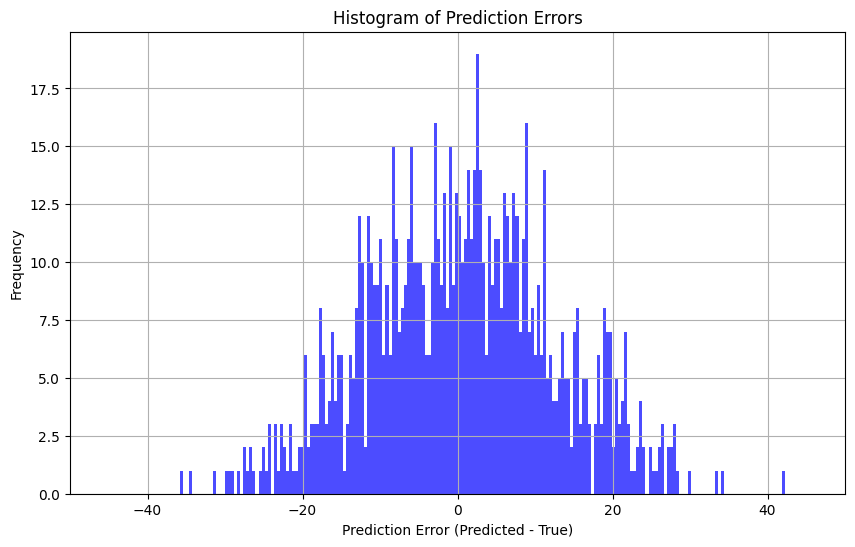

In [21]:
# Histogram of the errors
plt.figure(figsize=(10, 6))
plt.hist(
    np.array(y_pred_test) - np.array(y_true_test), bins=200, color="blue", alpha=0.7
)
plt.xlim(-50, 50)
plt.title("Histogram of Prediction Errors")
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Frequency")
plt.grid()
plt.show()